In [1]:
!pip install stable_baselines3
!pip install gymnasium[atari,accept-rom-license]
!pip install ale-py

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-intel 2.13.0 requires typing-extensions<4.6.0,>=3.6.6, but you have typing-extensions 4.13.2 which is incompatible.



  Attempting uninstall: typing-extensions
    Found existing installation: typing_extensions 4.5.0
    Uninstalling typing_extensions-4.5.0:
      Successfully uninstalled typing_extensions-4.5.0


In [1]:
import os
import random
import time

import ale_py
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.distributions import Categorical
from stable_baselines3.common.buffers import RolloutBuffer
from stable_baselines3.common.atari_wrappers import (
    ClipRewardEnv,
    EpisodicLifeEnv,
    FireResetEnv,
    MaxAndSkipEnv,
    NoopResetEnv,
)

In [2]:
# settings
env_id  = "BreakoutNoFrameskip-v4"

# number of environments to run in parallel
num_envs = 1

# Number of steps to collect per environment before update (N)
n_steps = 5

# total number of timesteps for training over multiple episodes
total_timesteps = 10_000_000

# adam learning rate
learning_rate = 2e-4

# discount factor
gamma = 0.99

# GAE lambda parameter
gae_lambda = 0.95 # Common default value for GAE

# optional: set seed for reproducibility
# seed = 123
seed = None

# entropy coefficient for loss
entropy_weight = 0.01

# value function coefficient for loss
value_weight = 0.25

# max L2-norm for gradient clipping
max_norm = 0.5

# where to save videos
video_path = "videos_a2c_gae_atari"

In [3]:
# will encapsulate in lambda later
def make_env(env_id, capture_video, seed=None):
  if capture_video:
    env = gym.make(env_id, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(env, "videos",
                                   episode_trigger=lambda episode: True)
  else:
    env = gym.make(env_id)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  env = NoopResetEnv(env, noop_max=30)
  env = MaxAndSkipEnv(env, skip=4)
  env = EpisodicLifeEnv(env)

  if "FIRE" in env.unwrapped.get_action_meanings():
    env = FireResetEnv(env)
  env = ClipRewardEnv(env)

  env = gym.wrappers.ResizeObservation(env, (84, 84))
  env = gym.wrappers.GrayscaleObservation(env)
  env = gym.wrappers.FrameStackObservation(env, 4)

  # for reproducibility
  if seed is not None:
    env.action_space.seed(seed)
  return env

In [4]:
env_id  = 'SpaceInvaders-v4'

# number of environments to run in parallel
num_envs = 1

# total number of timesteps for training over multiple episodes
total_timesteps = 1_000_000

In [5]:
class ActorCritic(nn.Module):
  def __init__(self, envs):
    super().__init__()

    n_input_channels = envs.single_observation_space.shape[0]
    self.cnn = nn.Sequential(
        nn.Conv2d(n_input_channels, 32, kernel_size=8, stride=4, padding=0),
        nn.ReLU(),
        nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=0),
        nn.ReLU(),
        nn.Conv2d(64, 64, kernel_size=3, stride=1, padding=0),
        nn.ReLU(),
        nn.Flatten(),
    )

    # Compute shape by doing one forward pass
    with torch.no_grad():
      n_flatten = self.cnn(
          torch.as_tensor(
              envs.single_observation_space.sample()[None]).float()).shape[1]

    self.linear = nn.Sequential(
        nn.Linear(n_flatten, 512),
        nn.ReLU(),
    )

    # Actor (Policy) Head
    self.actor = nn.Linear(512, envs.single_action_space.n)

    # Critic (Value Function) Head
    self.critic = nn.Linear(512, 1)

  def forward(self, x):
    features = self.cnn(x / 225.0)
    shared_latent = self.linear(features)

    return self.actor(shared_latent), self.critic(shared_latent)

In [6]:
#env_id  = 'SpaceInvaders-v4'

# number of environments to run in parallel
#num_envs = 1

# total number of timesteps for training over multiple episodes
#total_timesteps = 1_000_000

In [7]:
# make environments
#envs = gym.vector.SyncVectorEnv([
#    lambda: make_env(env_id, False, seed + i if seed is not None else None)
#    for i in range(num_envs)
#])

In [8]:
# optional: set seeds for reproducibility
if seed is not None:
  torch.manual_seed(seed)
  random.seed(seed)
  np.random.seed(seed)
  if torch.cuda.is_available():
    torch.backends.cudnn.deterministic = True

In [9]:
# set device
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# On Mac, MPS faster than CPU
device = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)

In [10]:
envs = gym.vector.SyncVectorEnv([
    lambda: make_env(
        env_id,
        False,
        seed if seed is None else seed + i) for i in range(num_envs)
])

In [11]:
# make neural network
ac_network = ActorCritic(envs).to(device)
optimizer = optim.Adam(ac_network.parameters(), lr=learning_rate, eps=1e-5)

D:\anaconda\envs\tf2\lib\site-packages\torch\cuda\__init__.py:230: UserWarning: 
NVIDIA GeForce RTX 5060 Laptop GPU with CUDA capability sm_120 is not compatible with the current PyTorch installation.
The current PyTorch install supports CUDA capabilities sm_37 sm_50 sm_60 sm_61 sm_70 sm_75 sm_80 sm_86 sm_90 compute_37.
If you want to use the NVIDIA GeForce RTX 5060 Laptop GPU GPU with PyTorch, please check the instructions at https://pytorch.org/get-started/locally/

  warnings.warn(


In [12]:
rollout_buffer = RolloutBuffer(
    buffer_size=n_steps,
    observation_space=envs.single_observation_space,
    action_space=envs.single_action_space,
    device=device,
    gamma=gamma,
    gae_lambda=gae_lambda,
    n_envs=num_envs,
)

In [13]:
# sample an action from logits
def sample_action(logits):
  distribution = Categorical(logits=logits)
  return distribution.sample()

In [14]:
# compute entropy for loss regularization
def compute_entropy_and_log_probs(policy_logits, actions):
  distribution = Categorical(logits=policy_logits)
  entropy = distribution.entropy()
  log_probs = distribution.log_prob(actions)
  return entropy.mean(), log_probs

In [15]:
def np2torch(a, dtype=torch.float32, device=device):
  return torch.as_tensor(a, dtype=dtype, device=device)

In [16]:
# training loop
episode_returns = []
losses = []

The RolloutBuffer is a buffer in the Stable-Baselines3 library used for storing data from the interaction between an agent and the environment, particularly when using policy gradient algorithms such as PPO and A2C. Its primary function is to collect data from one or more rollouts (episodes), including states, actions, rewards, termination flags, etc., and to calculate advantage estimates and returns for training the policy network and value function network.

Specifically, the functions of the RolloutBuffer include:

​Data Storage:​​ During interaction with the environment, it stores the state (observations), actions, rewards, termination flags (dones), as well as log probabilities (log_probs) and value function estimates (values) for each step.

​Calculating Advantage Estimates and Returns:​​ After an episode concludes or a certain number of steps is reached, it uses the Generalized Advantage Estimation (GAE) method to calculate advantage estimates and computes the returns for each state.

​Providing Data Sampling:​​ During training, the data in the buffer can be randomly sampled into multiple minibatches for updating network parameters.

The RolloutBuffer is designed to support on-policy algorithms, meaning it uses data collected by the current policy to update the policy itself. Once the data is used for training, the buffer is cleared to collect new data.

​Example usage workflow:​​

Initialize the buffer.

For each step:

Select an action using the current policy and execute an environment step.

Add the obtained data (obs, action, reward, done, value, log_prob) to the buffer.

When the buffer reaches its capacity (or an episode ends), use the last step's last_valueand donesto calculate returns and advantages.

Sample minibatches of data from the buffer and perform multiple training updates.

Reset the buffer and continue collecting data.

Note: The RolloutBuffer is typically used with on-policy algorithms, as off-policy algorithms usually employ a ReplayBuffer to store and sample past data.

RolloutBuffer‘s method
    #return_t = advantage_t + values[t]
    #A_t = δ_t + (γλ) * δ{t+1} + (γλ)^2 * δ{t+2} + ... + (γλ)^{n-t-1} * δ_{n-1}
    #where δ_t = r_t + γ * V(s_{t+1}) - V(s_t)

actaully implementation
def compute_returns_and_advantage(self, last_values, dones):
    # return's discount
    returns = torch.zeros_like(self.rewards)
    advantages = torch.zeros_like(self.rewards)
    
    last_gae_lam = 0
    for step in reversed(range(self.buffer_size)):
        if step == self.buffer_size - 1:
            next_values = last_values
        else:
            next_values = self.values[step + 1]
        
        delta = self.rewards[step] + self.gamma * next_values * (1 - self.dones[step]) - self.values[step]
        last_gae_lam = delta + self.gamma * self.gae_lambda * (1 - self.dones[step]) * last_gae_lam
        advantages[step] = last_gae_lam
    
    # return = valuse + advantage
    returns = advantages + self.values

In [17]:
global_step = 0
start_time = time.time()

# reset env
obs, _ = envs.reset(seed=seed)

# Main training loop
while global_step < total_timesteps:

  # Rollout phase
  for step in range(n_steps):
    # Convert obs to tensor
    obs_tensor = np2torch(obs)

    # Forward pass through the network
    with torch.no_grad():
      policy_logits, values = ac_network(obs_tensor)
      actions = sample_action(policy_logits)
      _, log_probs = compute_entropy_and_log_probs(policy_logits, actions)

    # Take actions in the environment
    actions_np = actions.cpu().numpy()
    next_obs, rewards, terminateds, truncateds, infos = envs.step(actions_np)
    dones = terminateds | truncateds

    # Store data in buffer
    rollout_buffer.add(
        obs,
        actions_np,
        rewards,
        terminateds,
        values.squeeze(-1),
        log_probs,
    )

    # Update observations
    obs = next_obs

    for i, (terminated, truncated) in enumerate(zip(terminateds, truncateds)):
      if terminated or truncated:
        # This only appears when all lives are lost
        if 'episode' in infos:
          ret = infos['episode']['r'][i]
          episode_returns.append(ret)
          print(f"global_step={global_step}, episode={len(episode_returns)}, episode_return={ret}")
     # end for step in range(n_steps):   collect data for n_steps=5 


    
  # Update AC phase
  with torch.no_grad():
    _, last_values = ac_network(np2torch(next_obs))
    last_dones = dones

  rollout_buffer.compute_returns_and_advantage(
      last_values=last_values.squeeze(-1), dones=last_dones)

   
    

  # This will only loop once (get all data in one go)
  for rollout_data in rollout_buffer.get(batch_size=None):

    observations_arr = rollout_data.observations
    actions_arr = rollout_data.actions.flatten()
    advantages_arr = rollout_data.advantages
    returns_arr = rollout_data.returns

    # Calculate
    new_logits, new_values = ac_network(observations_arr)
    entropy, new_log_probs = compute_entropy_and_log_probs(
        new_logits, actions_arr)
    new_values = new_values.flatten()

    # Value Loss (MSE),we have n-step, thus we have n-step's  new_values
    value_loss = F.mse_loss(new_values, returns_arr)

    # Polciy Loss, ,we have n-step, thus we have n-step's  advantages_arr
    policy_loss = -(advantages_arr * new_log_probs).mean()

    # Entropy Loss
    entropy_loss = -entropy

    # Total Loss
    loss = policy_loss + value_weight * value_loss + entropy_weight * entropy_loss

    # Store losses for plotting
    losses.append(loss.item())

    # Update network
    optimizer.zero_grad()
    loss.backward()
    nn.utils.clip_grad_norm_(ac_network.parameters(), max_norm)
    optimizer.step()

    # AC network will begin in next n-step, the data produced is based on the trained AC.
    # So AC is online model
    
  # Important: reset the buffer
  # If you don't do this, observations will have the wrong shape!
  # It flattens from (N, num_envs, 4, 84, 84) --> (N * num_envs, 4, 84, 84)
  rollout_buffer.reset()

  # Update global step counter
  global_step += n_steps * num_envs

  # Logging
  if global_step % (100 * n_steps * num_envs) == 0 and len(episode_returns) > 100: # Log approx every 100 updates
    print(f"Global Step: {global_step} / {total_timesteps}")
    print(f"  Loss: {loss.item():.4f} (Policy: {policy_loss.item():.4f}, Value: {value_loss.item():.4f}, Entropy: {-entropy_loss.item():.4f})") # print positive entropy
    if episode_returns:
        print(f"  Mean Return (last 100): {np.mean(episode_returns[-100:]):.2f}")
    print(f"  Steps per second: {int(global_step / (time.time() - start_time))}")

# close
envs.close()

global_step=120, episode=1, episode_return=95.0
global_step=300, episode=2, episode_return=110.0
global_step=390, episode=3, episode_return=35.0
global_step=630, episode=4, episode_return=380.0
global_step=725, episode=5, episode_return=50.0
global_step=875, episode=6, episode_return=125.0
global_step=1035, episode=7, episode_return=150.0
global_step=1125, episode=8, episode_return=15.0
global_step=1220, episode=9, episode_return=110.0
global_step=1365, episode=10, episode_return=90.0
global_step=1445, episode=11, episode_return=60.0
global_step=1605, episode=12, episode_return=155.0
global_step=1715, episode=13, episode_return=45.0
global_step=1905, episode=14, episode_return=265.0
global_step=2050, episode=15, episode_return=110.0
global_step=2215, episode=16, episode_return=45.0
global_step=2475, episode=17, episode_return=165.0
global_step=2670, episode=18, episode_return=135.0
global_step=2890, episode=19, episode_return=165.0
global_step=2995, episode=20, episode_return=45.0
glob

KeyboardInterrupt: 

In [18]:
def smooth(x, a=0.1):
    y = [x[0]]
    for xi in x[1:]:
        yi = a * xi + (1 - a) * y[-1]
        y.append(yi)
    return y

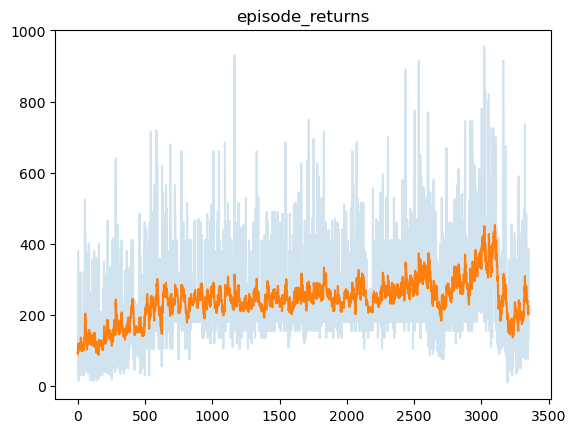

In [19]:
plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");

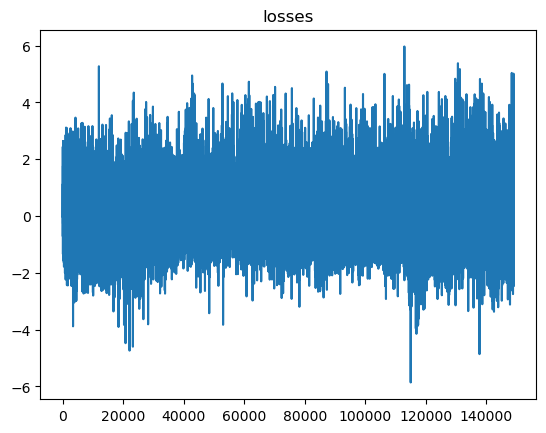

In [20]:
plt.plot(losses)
plt.title("losses");

In [21]:
# --- Save Model ---
model_path = f"a2c_gae_atari_{env_id}.pth"
print(f"Saving model to {model_path}")
torch.save(ac_network.state_dict(), model_path)

Saving model to a2c_gae_atari_SpaceInvaders-v4.pth


In [25]:
# --- Evaluation Phase ---

# load model for eval
#envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)],
#    autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(env_id, True)])
model = ActorCritic(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

D:\anaconda\envs\tf2\lib\site-packages\gymnasium\wrappers\rendering.py:283: UserWarning: WARN: Overwriting existing videos at E:\reinforcing\notebooks\rl2v2\videos folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(
C:\Users\yxzha\AppData\Local\Temp\ipykernel_3772\372898736.py:8: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_sa

ActorCritic(
  (cnn): Sequential(
    (0): Conv2d(4, 32, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (5): ReLU()
    (6): Flatten(start_dim=1, end_dim=-1)
  )
  (linear): Sequential(
    (0): Linear(in_features=3136, out_features=512, bias=True)
    (1): ReLU()
  )
  (actor): Linear(in_features=512, out_features=6, bias=True)
  (critic): Linear(in_features=512, out_features=1, bias=True)
)

In [26]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    with torch.no_grad():
      logits, _ = model(np2torch(obs))
      actions = sample_action(logits)
      actions = actions.cpu().numpy()
      obs, rewards, terminateds, truncateds, infos = envs_eval.step(actions)
      if terminateds[0] or truncateds[0]:
        if 'final_info' in infos:
          if 'episode' in infos['final_info']:
            episode_done = True
            ret = infos['final_info']["episode"]["r"][0]
            print(f"episode={i}, return={ret}")
            eval_returns[i] = ret
envs_eval.close()

KeyboardInterrupt: 

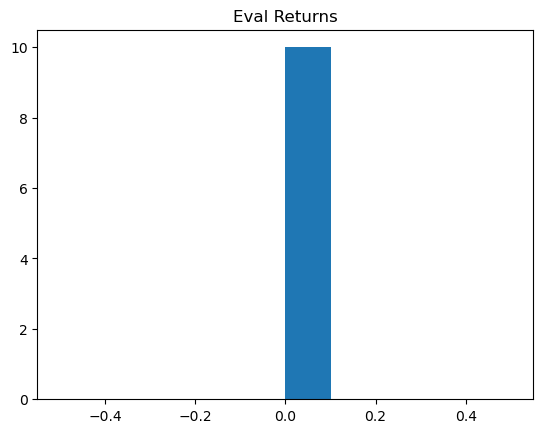

In [24]:
# plot the eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns")
plt.show();

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=qsKxUjkGj_Qk9wyS1St9Jw&n=A2C+Atari)